## Grid Search Hyperparameter optimization

This case study is all about using grid searches to identify the optimal parameters for a machine learning algorithm. To complere this case study, you'll use the Pima Indian diabetes dataset from Kaggle and KNN. Follow along with the preprocessing steps of this case study.

Load the necessary packages

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

# set random seed to try make this exercise and solutions reproducible (NB: this is just for teaching purpose and not something you would do in real life)
random_seed_number = 42
np.random.seed(random_seed_number)

#### Load the diabetes data

In [6]:
diabetes_data = pd.read_csv('data/diabetes.csv')
diabetes_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


**<font color='teal'> Start by reviewing the data info.</font>**

In [7]:
diabetes_data.info

<bound method DataFrame.info of      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   5

**<font color='teal'> Apply the describe function to the data.</font>**

In [8]:
diabetes_data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


**<font color='teal'> Currently, the missing values in the dataset are represented as zeros. Replace the zero values in the following columns ['Glucose','BloodPressure','SkinThickness','Insulin','BMI'] with nan .</font>**

In [9]:
# Replace zero values with NaN in specified columns
columns_to_replace = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
diabetes_data[columns_to_replace] = diabetes_data[columns_to_replace].replace(0, np.nan)

# Verify the changes by checking the count of non-null values
print("\nAfter replacing zeros with NaN:")
print(diabetes_data[columns_to_replace].describe())


After replacing zeros with NaN:
          Glucose  BloodPressure  SkinThickness     Insulin         BMI
count  763.000000     733.000000     541.000000  394.000000  757.000000
mean   121.686763      72.405184      29.153420  155.548223   32.457464
std     30.535641      12.382158      10.476982  118.775855    6.924988
min     44.000000      24.000000       7.000000   14.000000   18.200000
25%     99.000000      64.000000      22.000000   76.250000   27.500000
50%    117.000000      72.000000      29.000000  125.000000   32.300000
75%    141.000000      80.000000      36.000000  190.000000   36.600000
max    199.000000     122.000000      99.000000  846.000000   67.100000


**<font color='teal'> Plot histograms of each column. </font>**

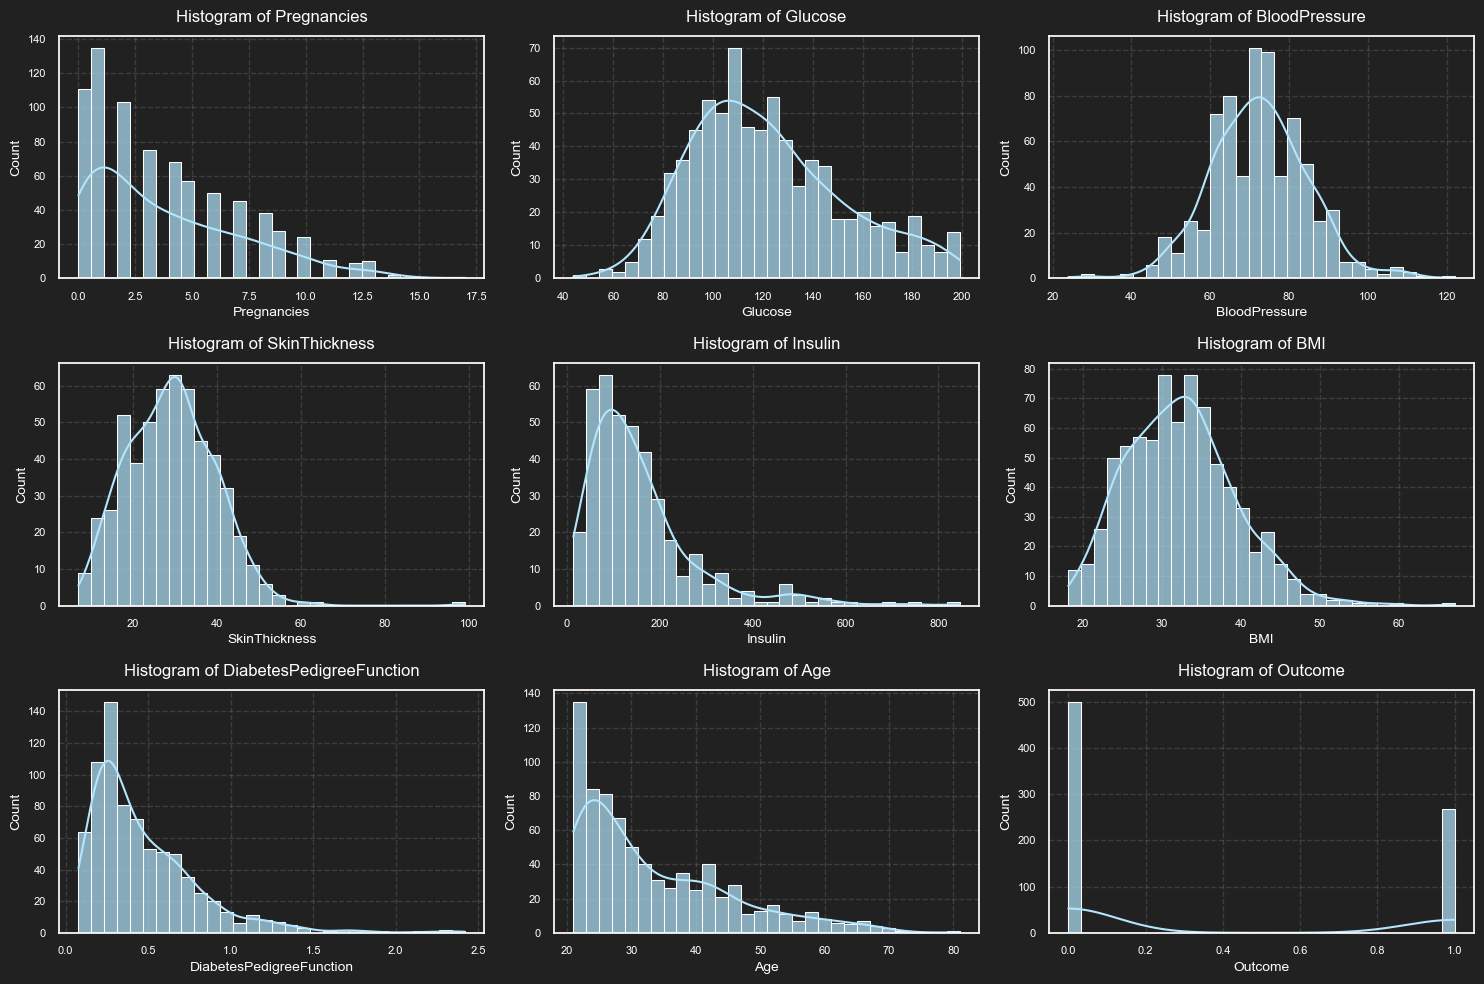

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set seaborn dark theme for dark mode
sns.set_style("darkgrid")  # Dark grid style
plt.rcParams['figure.facecolor'] = '#212121'  # Dark background for the figure
plt.rcParams['axes.facecolor'] = '#212121'   # Dark background for axes

# Create a figure with subplots (3 rows, 3 columns for 9 features)
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

# List of columns
columns = diabetes_data.columns

# Define a light color for bars
light_color = '#B3E5FC'  # Light blue

# Plot histogram for each column with light bars and ensure labels are visible
for i, col in enumerate(columns):
    sns.histplot(data=diabetes_data, x=col, ax=axes[i], kde=True, bins=30, color=light_color, alpha=0.7)
    
    # Set title and labels with explicit styling
    axes[i].set_title(f'Histogram of {col}', color='white', fontsize=12, pad=10)
    axes[i].set_xlabel(col, color='white', fontsize=10)
    axes[i].set_ylabel('Count', color='white', fontsize=10)
    
    # Ensure tick labels are visible
    axes[i].tick_params(axis='x', colors='white', labelsize=8)
    axes[i].tick_params(axis='y', colors='white', labelsize=8)
    
    # Add grid for better visibility (already set by darkgrid)
    axes[i].grid(True, color='gray', linestyle='--', alpha=0.3)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()

#### Replace the zeros with mean and median values.

In [20]:
diabetes_data['Glucose'].fillna(diabetes_data['Glucose'].mean())
diabetes_data['BloodPressure'].fillna(diabetes_data['BloodPressure'].mean())
diabetes_data['SkinThickness'].fillna(diabetes_data['SkinThickness'].median())
diabetes_data['Insulin'].fillna(diabetes_data['Insulin'].median())
diabetes_data['BMI'].fillna(diabetes_data['BMI'].median())

0      33.6
1      26.6
2      23.3
3      28.1
4      43.1
       ... 
763    32.9
764    36.8
765    26.2
766    30.1
767    30.4
Name: BMI, Length: 768, dtype: float64

**<font color='teal'> Plot histograms of each column after replacing nan. </font>**

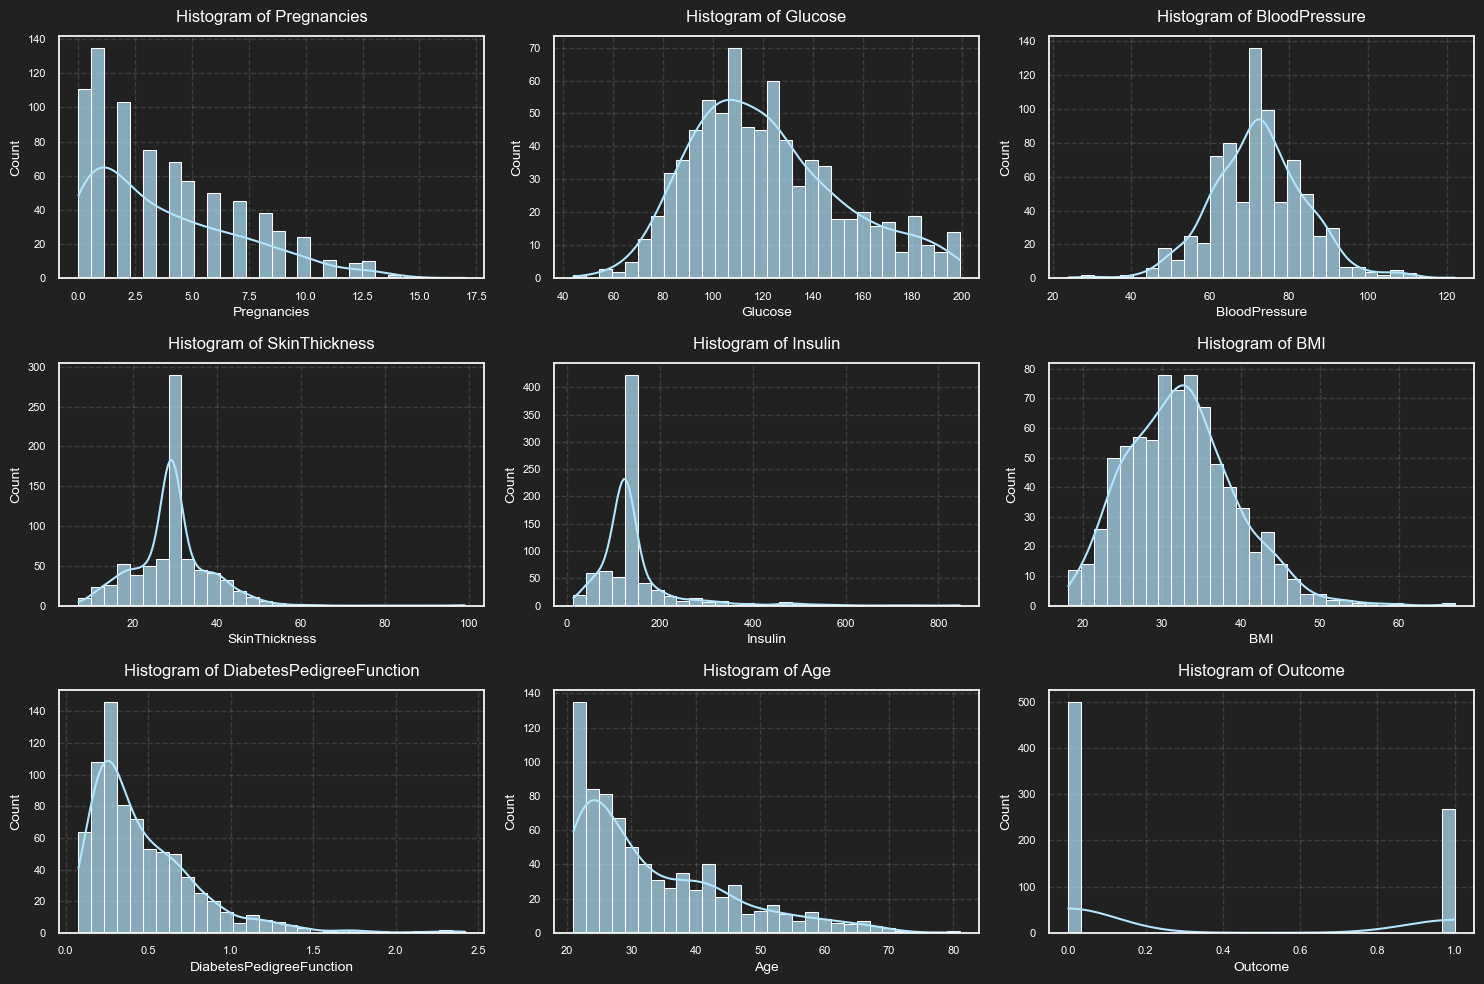

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set seaborn dark theme for dark mode
sns.set_style("darkgrid")  # Dark grid style
plt.rcParams['figure.facecolor'] = '#212121'  # Dark background for the figure
plt.rcParams['axes.facecolor'] = '#212121'   # Dark background for axes

# Create a figure with subplots (3 rows, 3 columns for 9 features)
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

# List of columns
columns = diabetes_data.columns

# Define a light color for bars
light_color = '#B3E5FC'  # Light blue

# Plot histogram for each column with light bars and ensure labels are visible
for i, col in enumerate(columns):
    sns.histplot(data=diabetes_data, x=col, ax=axes[i], kde=True, bins=30, color=light_color, alpha=0.7)
    
    # Set title and labels with explicit styling
    axes[i].set_title(f'Histogram of {col}', color='white', fontsize=12, pad=10)
    axes[i].set_xlabel(col, color='white', fontsize=10)
    axes[i].set_ylabel('Count', color='white', fontsize=10)
    
    # Ensure tick labels are visible
    axes[i].tick_params(axis='x', colors='white', labelsize=8)
    axes[i].tick_params(axis='y', colors='white', labelsize=8)
    
    # Add grid for better visibility (already set by darkgrid)
    axes[i].grid(True, color='gray', linestyle='--', alpha=0.3)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()

#### Plot the correlation matrix heatmap

Correlation between various features


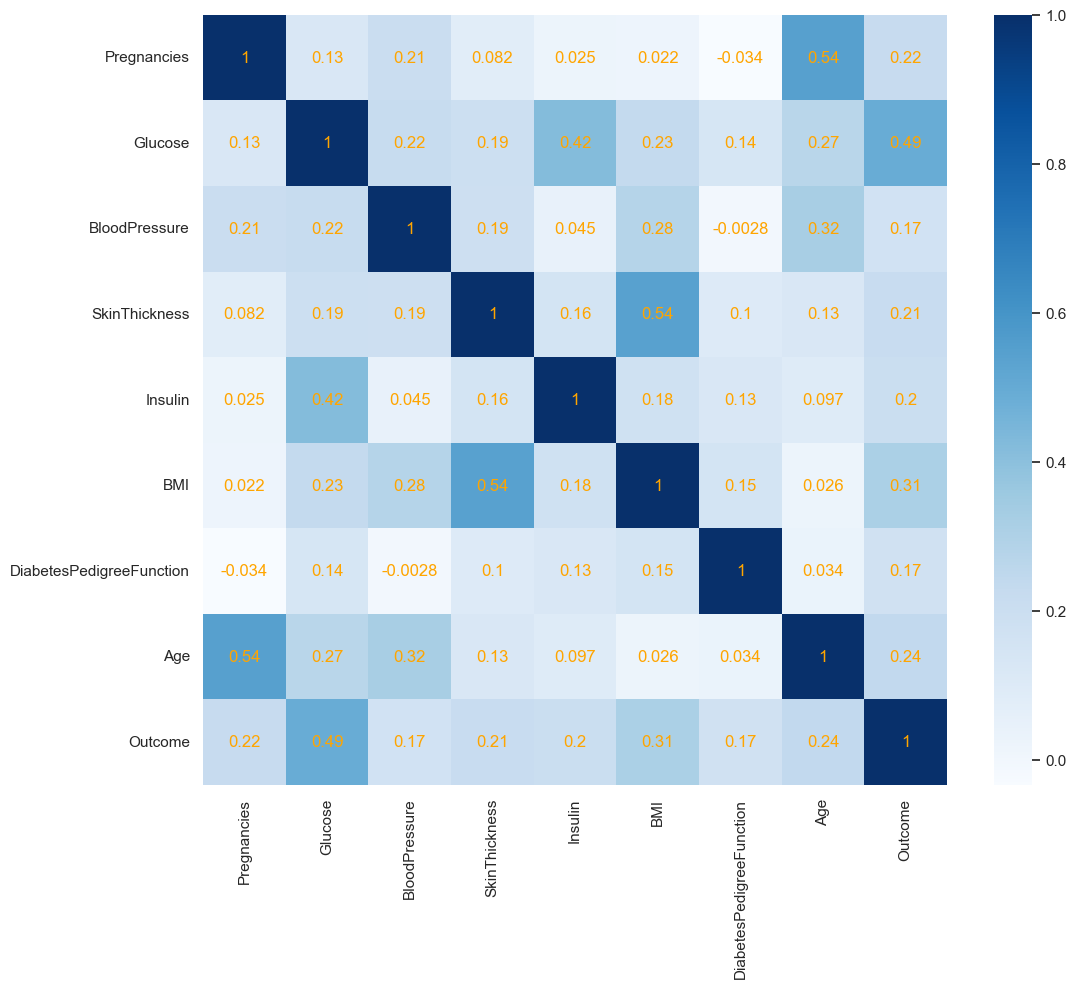

In [55]:
plt.figure(figsize=(12,10))
print('Correlation between various features')
p=sns.heatmap(diabetes_data.corr(), annot=True,cmap ='Blues')

# Get current Axes instance on the current figure 
ax = plt.gca()

# Iterate through each cell in the heatmap
for text in ax.texts:
    text.set_color('orange')  # Change label color to orange

**<font color='teal'> Define the `y` variable as the `Outcome` column.</font>**

In [25]:
# Define y variable as the Outcome column
y = diabetes_data['Outcome']

**<font color='teal'> Create a 70/30 train and test split. </font>**

In [26]:
from sklearn.model_selection import train_test_split

# Define X variable as all columns except Outcome
X = diabetes_data.drop('Outcome', axis=1)

# Create a 70/30 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

**<font color='teal'> Using Sklearn, standardize the magnitude of the features by scaling the values. </font>**

Note: Don't forget to fit() your scaler on X_train and then use that fitted scaler to transform() X_test. This is to avoid data leakage while you standardize your data.

In [27]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on X_train only
scaler.fit(X_train)

# Transform X_train and X_test using the fitted scaler
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert the scaled arrays back to DataFrames for easier handling (optional)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

# Print the first few rows of scaled training data to verify
print("\nFirst few rows of scaled X_train:")
print(X_train_scaled.head())


First few rows of scaled X_train:
   Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0    -0.836294 -0.896108      -1.004400      -1.269545 -0.956993 -1.203826   
1     0.390728 -0.563997      -0.020266       0.029693  2.136797  0.664498   
2    -1.143050  0.432336      -0.348311       1.565156  1.267755  1.440571   
3     0.083972  0.299491      -0.348311      -0.915207  0.294428  0.118373   
4    -0.836294 -0.630419      -3.464737       1.092706 -0.667312  1.584288   

   DiabetesPedigreeFunction       Age  
0                 -0.614216 -0.948610  
1                 -0.909738 -0.434667  
2                 -0.306991 -0.777296  
3                 -0.906812 -0.434667  
4                 -0.839515 -0.006380  


#### Using a range of neighbor values of 1-10, apply the KNearestNeighbor classifier to classify the the data.

In [28]:
from sklearn.neighbors import KNeighborsClassifier


test_scores = []
train_scores = []

for i in range(1,10):

    knn = KNeighborsClassifier(i)
    knn.fit(X_train,y_train)
    
    train_scores.append(knn.score(X_train,y_train))
    test_scores.append(knn.score(X_test,y_test))

**<font color='teal'> Print the train and test scores for each iteration.</font>**

In [32]:
from sklearn.neighbors import KNeighborsClassifier

test_scores = []
train_scores = []


for i in range(1, 10):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_scaled, y_train)
    train_score = knn.score(X_train_scaled, y_train)
    test_score = knn.score(X_test_scaled, y_test)
    train_scores.append(train_score)
    test_scores.append(test_score)
    print(f"k = {i}: Train Score = {train_score:.4f}, Test Score = {test_score:.4f}")


# Print the final lists of scores (optional)
print("\nFinal Train Scores:", train_scores)
print("Final Test Scores:", test_scores)

k = 1: Train Score = 1.0000, Test Score = 0.6667
k = 2: Train Score = 0.8510, Test Score = 0.6710
k = 3: Train Score = 0.8547, Test Score = 0.6710
k = 4: Train Score = 0.8417, Test Score = 0.6926
k = 5: Train Score = 0.8399, Test Score = 0.7013
k = 6: Train Score = 0.8231, Test Score = 0.6840
k = 7: Train Score = 0.8343, Test Score = 0.7316
k = 8: Train Score = 0.8212, Test Score = 0.7359
k = 9: Train Score = 0.8268, Test Score = 0.7316

Final Train Scores: [1.0, 0.851024208566108, 0.8547486033519553, 0.8417132216014898, 0.839851024208566, 0.8230912476722533, 0.8342644320297952, 0.8212290502793296, 0.8268156424581006]
Final Test Scores: [0.6666666666666666, 0.670995670995671, 0.670995670995671, 0.6926406926406926, 0.7012987012987013, 0.683982683982684, 0.7316017316017316, 0.7359307359307359, 0.7316017316017316]


**<font color='teal'> Identify the number of neighbors that resulted in the max score in the training dataset. </font>**

Maximum Train Score: k = 1 (Score = 1.0000)


**<font color='teal'> Identify the number of neighbors that resulted in the max score in the testing dataset. </font>**

Maximum Test Score: k = 8 (Score = 0.7359)

Plot the train and test model performance by number of neighbors.

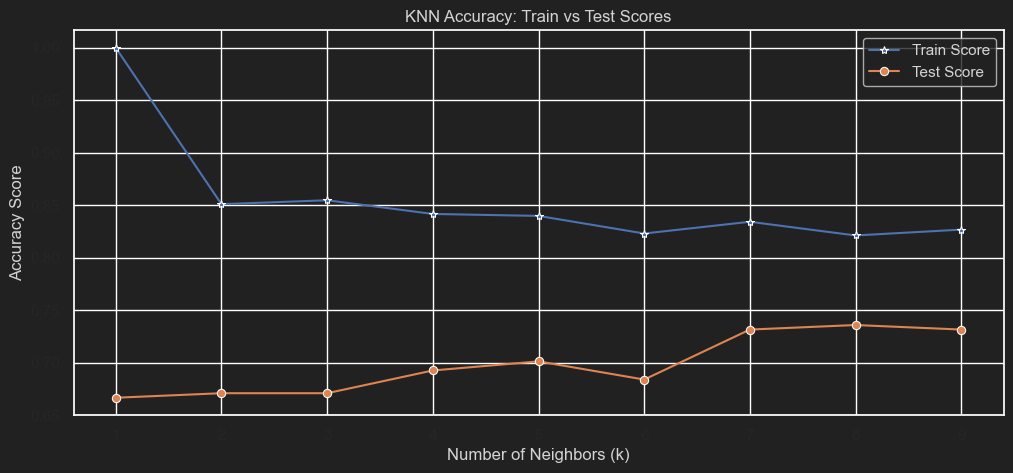

In [38]:
plt.figure(figsize=(12,5))
# p = sns.lineplot(range(1,10),train_scores,marker='*',label='Train Score')
# p = sns.lineplot(range(1,10),test_scores,marker='o',label='Test Score')
# Specify the color for the labels
color = "lightgray"

p = sns.lineplot(x=list(range(1, 10)), y=train_scores, marker='*', label='Train Score')
p = sns.lineplot(x=list(range(1, 10)), y=test_scores, marker='o', label='Test Score')
# Change the color of labels
plt.xlabel("Number of Neighbors (k)", color=color)
plt.ylabel("Accuracy Score", color=color)

# Change legend label color
legend = plt.legend()
plt.setp(legend.get_texts(), color=color)

# Add title (optional but recommended)
plt.title("KNN Accuracy: Train vs Test Scores", color=color)
plt.show()

**<font color='teal'> Fit and score the best number of neighbors based on the plot. </font>**

Lines:


Train Score (blue line with * markers): Starts high at k=1 (near 1.0) and decreases gradually as k increases.


Test Score (orange line with o markers): Starts lower at k=1, increases to a peak, and then fluctuates or slightly decreases.

the best number of neighbors is k=8. Fit the KNN classifier with k=8 on the training data and score it on both the training and test sets.

X_train shape: (537, 8)
X_test shape: (231, 8)
y_train shape: (537,)
y_test shape: (231,)

Best number of neighbors (k) = 8
Train Score with k=8: 0.8212
Test Score with k=8: 0.7359


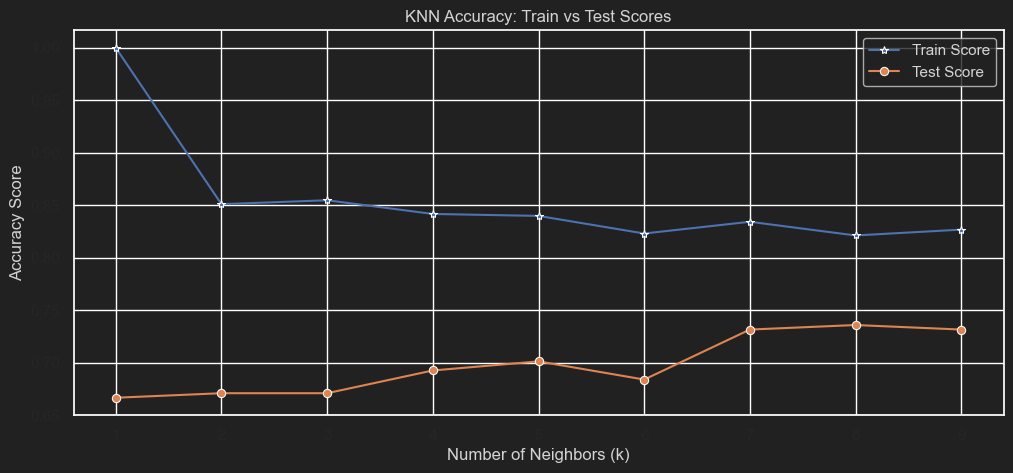

In [39]:
#Create a 70/30 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Print the shapes to verify the split
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on X_train only and transform both X_train and X_test
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert the scaled arrays back to DataFrames
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

# Apply K-Nearest Neighbors Classifier with the best k (k=8)
best_k = 8
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)

# Score the model on train and test sets
train_score = knn.score(X_train_scaled, y_train)
test_score = knn.score(X_test_scaled, y_test)

# Print the scores
print(f"\nBest number of neighbors (k) = {best_k}")
print(f"Train Score with k={best_k}: {train_score:.4f}")
print(f"Test Score with k={best_k}: {test_score:.4f}")

# Plot the scores for reference
test_scores = []
train_scores = []
for i in range(1, 10):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_scaled, y_train)
    train_scores.append(knn.score(X_train_scaled, y_train))
    test_scores.append(knn.score(X_test_scaled, y_test))

plt.figure(figsize=(12, 5))
color = "lightgray"
p = sns.lineplot(x=list(range(1, 10)), y=train_scores, marker='*', label='Train Score')
p = sns.lineplot(x=list(range(1, 10)), y=test_scores, marker='o', label='Test Score')
plt.xlabel("Number of Neighbors (k)", color=color)
plt.ylabel("Accuracy Score", color=color)
legend = plt.legend()
plt.setp(legend.get_texts(), color=color)
plt.title("KNN Accuracy: Train vs Test Scores", color=color)
plt.show()

In [40]:
from sklearn.metrics import confusion_matrix
y_pred = knn.predict(X_test)
pl = confusion_matrix(y_test,y_pred)

**<font color='teal'> Plot the confusion matrix for the model fit above. </font>**

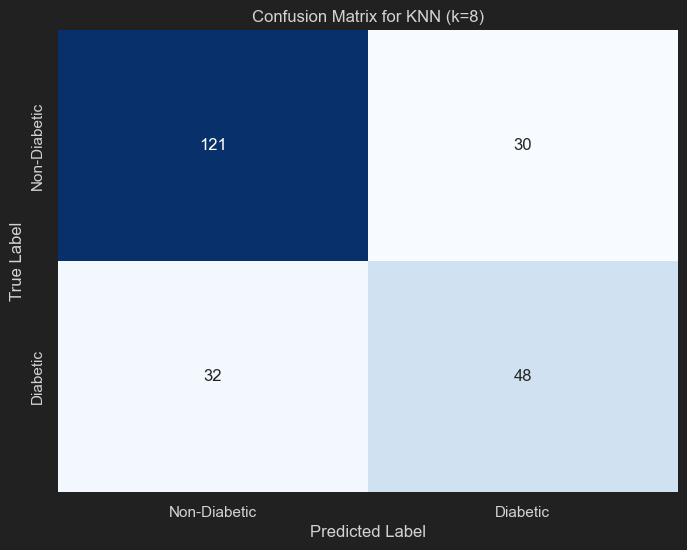

In [43]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


# Predict on the scaled test data
y_pred = knn.predict(X_test_scaled)

# Compute and plot the confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix for KNN (k=8)", color='lightgray')
plt.xlabel("Predicted Label", color='lightgray')
plt.ylabel("True Label", color='lightgray')
plt.xticks(ticks=[0.5, 1.5], labels=['Non-Diabetic', 'Diabetic'], color='lightgray')
plt.yticks(ticks=[0.5, 1.5], labels=['Non-Diabetic', 'Diabetic'], color='lightgray')
plt.show()


**<font color='teal'> Print the classification report </font>**

In [44]:
print(cm)

[[121  30]
 [ 32  48]]


In [45]:

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
#Print the classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Non-Diabetic', 'Diabetic']))


Classification Report:
              precision    recall  f1-score   support

Non-Diabetic       0.79      0.80      0.80       151
    Diabetic       0.62      0.60      0.61        80

    accuracy                           0.73       231
   macro avg       0.70      0.70      0.70       231
weighted avg       0.73      0.73      0.73       231



#### In the case of the K nearest neighbors algorithm, the K parameter is one of the most important parameters affecting the model performance.  The model performance isn't horrible, but what if we didn't consider a wide enough range of values in our neighbors for the KNN? An alternative to fitting a loop of models is to use a grid search to identify the proper number. It is common practice to use a grid search method for all adjustable parameters in any type of machine learning algorithm. First, you define the grid — aka the range of values — to test in the parameter being optimized, and then compare the model outcome performance based on the different values in the grid.

#### Run the code in the next cell to see how to implement the grid search method for identifying the best parameter value for the n_neighbors parameter. Notice the param_grid is the range value to test and we apply cross validation with five folds to score each possible value of n_neighbors.

In [46]:
from sklearn.model_selection import GridSearchCV
param_grid = {'n_neighbors':np.arange(1,50)}
knn = KNeighborsClassifier()
knn_cv= GridSearchCV(knn,param_grid,cv=5)
knn_cv.fit(X,y)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49])})

#### Print the best score and best parameter for n_neighbors.

In [47]:
print("Best Score:" + str(knn_cv.best_score_))
print("Best Parameters: " + str(knn_cv.best_params_))

Best Score:0.7526440879382056
Best Parameters: {'n_neighbors': 31}


Here you can see that the ideal number of n_neighbors for this model is 14 based on the grid search performed. 

(Discrepancy in the number of neighbors: 31 vs 14). 

Correlation between various features


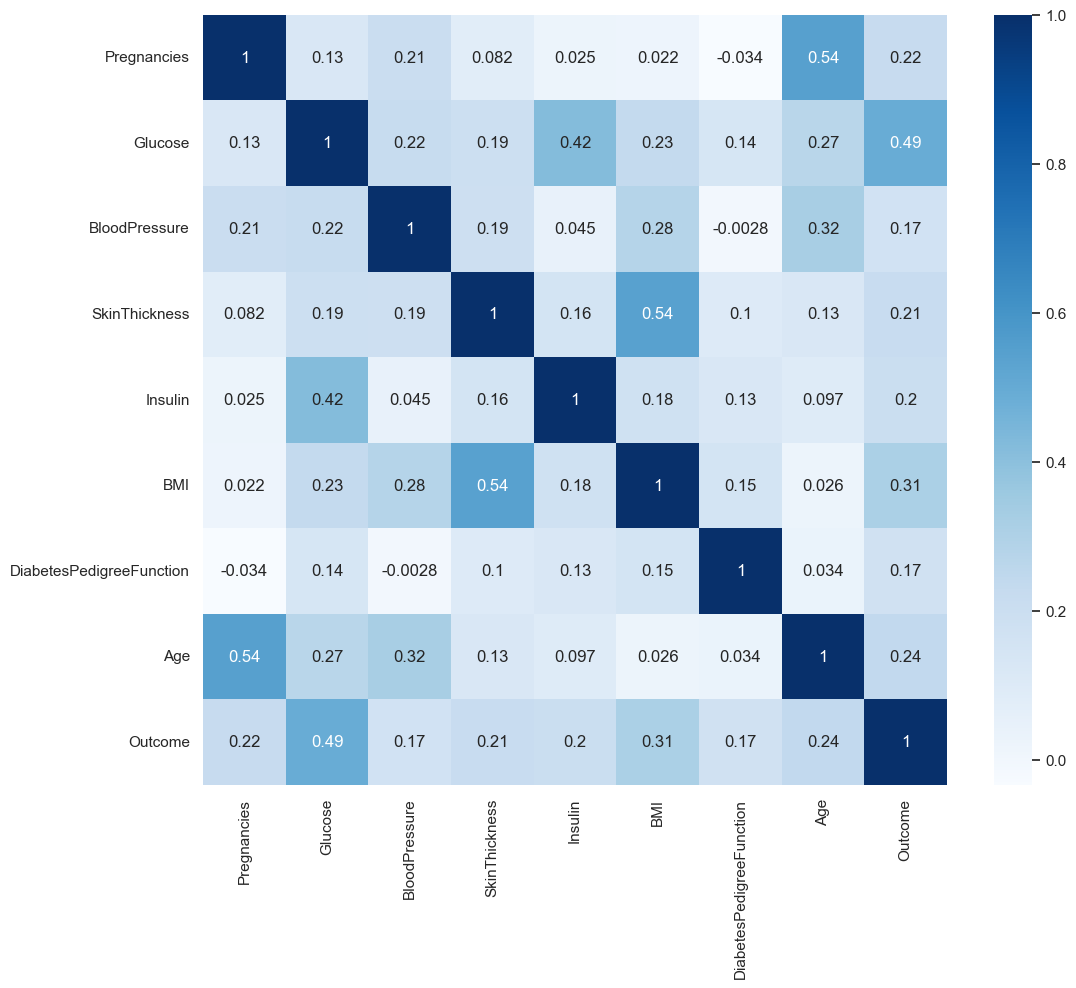

X_train shape: (537, 8)
X_test shape: (231, 8)
y_train shape: (537,)
y_test shape: (231,)

Best number of neighbors (k) = 11
Train Score with k=11: 0.8212
Test Score with k=11: 0.7186


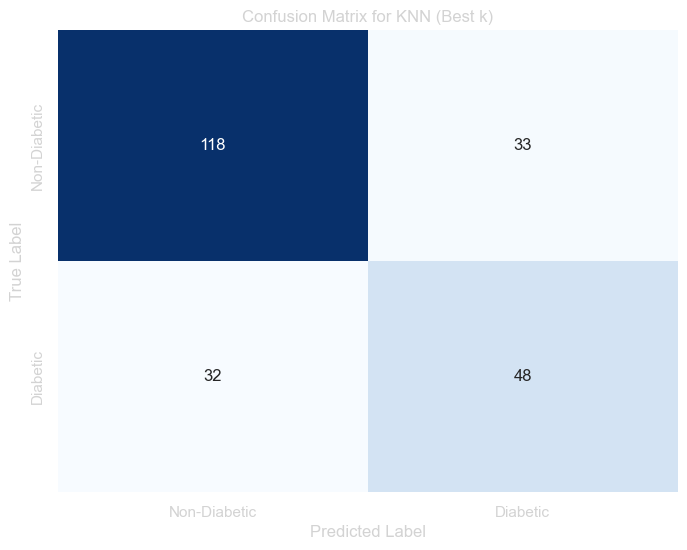


Classification Report:
              precision    recall  f1-score   support

Non-Diabetic       0.79      0.78      0.78       151
    Diabetic       0.59      0.60      0.60        80

    accuracy                           0.72       231
   macro avg       0.69      0.69      0.69       231
weighted avg       0.72      0.72      0.72       231



In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Replace infinite values with NaN and impute missing values
diabetes_data = diabetes_data.replace([np.inf, -np.inf], np.nan)
diabetes_data['Glucose'] = diabetes_data['Glucose'].fillna(diabetes_data['Glucose'].mean())
diabetes_data['BloodPressure'] = diabetes_data['BloodPressure'].fillna(diabetes_data['BloodPressure'].mean())
diabetes_data['SkinThickness'] = diabetes_data['SkinThickness'].fillna(diabetes_data['SkinThickness'].median())
diabetes_data['Insulin'] = diabetes_data['Insulin'].fillna(diabetes_data['Insulin'].median())
diabetes_data['BMI'] = diabetes_data['BMI'].fillna(diabetes_data['BMI'].median())

# Create heatmap 
plt.figure(figsize=(12, 10))
print('Correlation between various features')
sns.heatmap(diabetes_data.corr(), annot=True, cmap='Blues')
plt.show()

# Define y variable as the Outcome column
y = diabetes_data['Outcome']

# Define X variable as all columns except Outcome
X = diabetes_data.drop('Outcome', axis=1)

# Create a 70/30 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Print the shapes to verify the split
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on X_train only and transform both X_train and X_test
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert the scaled arrays back to DataFrames 
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

# Define the parameter grid for GridSearchCV
param_grid = {'n_neighbors': np.arange(1, 50)}

# Initialize the KNN classifier
knn = KNeighborsClassifier()

# Perform GridSearchCV on the scaled training data
knn_cv = GridSearchCV(knn, param_grid, cv=5)
knn_cv.fit(X_train_scaled, y_train)

# Get the best number of neighbors
best_k = knn_cv.best_params_['n_neighbors']
print(f"\nBest number of neighbors (k) = {best_k}")

# Fit the best model on the entire training set
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train_scaled, y_train)

# Score the best model on train and test sets
train_score = best_knn.score(X_train_scaled, y_train)
test_score = best_knn.score(X_test_scaled, y_test)
print(f"Train Score with k={best_k}: {train_score:.4f}")
print(f"Test Score with k={best_k}: {test_score:.4f}")

# Predict on the scaled test data
y_pred = best_knn.predict(X_test_scaled)

# Compute and plot the confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix for KNN (Best k)", color='lightgray')
plt.xlabel("Predicted Label", color='lightgray')
plt.ylabel("True Label", color='lightgray')
plt.xticks(ticks=[0.5, 1.5], labels=['Non-Diabetic', 'Diabetic'], color='lightgray')
plt.yticks(ticks=[0.5, 1.5], labels=['Non-Diabetic', 'Diabetic'], color='lightgray')
plt.show()

# Print the classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Non-Diabetic', 'Diabetic']))

K Best is now 11 (closer to 14):
Best number of neighbors (k) = 11
Train Score with k=11: 0.8212
Test Score with k=11: 0.7186

In [49]:
print("Best Score:" + str(knn_cv.best_score_))
print("Best Parameters: " + str(knn_cv.best_params_))

Best Score:0.7951021114572516
Best Parameters: {'n_neighbors': 11}


**<font color='teal'> Now, following the KNN example, apply this grid search method to find the optimal number of estimators in a Randon Forest model.
</font>**

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# R

# Define y variable as the Outcome column
y = diabetes_data['Outcome']

# Define X variable as all columns except Outcome
X = diabetes_data.drop('Outcome', axis=1)

# Create a 70/30 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Print the shapes to verify the split
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on X_train only and transform both X_train and X_test
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert the scaled arrays back to DataFrames (optional)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)



X_train shape: (537, 8)
X_test shape: (231, 8)
y_train shape: (537,)
y_test shape: (231,)


In [51]:
# Define the parameter grid for GridSearchCV
param_grid = {'n_estimators': np.arange(10, 201, 10)}  # Range from 10 to 200 with step 10

# Initialize the Random Forest classifier
rf = RandomForestClassifier(random_state=42)

# Perform GridSearchCV on the scaled training data
rf_cv = GridSearchCV(rf, param_grid, cv=5)
rf_cv.fit(X_train_scaled, y_train)

# Get the best number of estimators
best_n_estimators = rf_cv.best_params_['n_estimators']
print(f"\nBest number of estimators = {best_n_estimators}")

# Fit the best model on the entire training set
best_rf = RandomForestClassifier(n_estimators=best_n_estimators, random_state=42)
best_rf.fit(X_train_scaled, y_train)

# Score the best model on train and test sets
train_score = best_rf.score(X_train_scaled, y_train)
test_score = best_rf.score(X_test_scaled, y_test)
print(f"Train Score with n_estimators={best_n_estimators}: {train_score:.4f}")
print(f"Test Score with n_estimators={best_n_estimators}: {test_score:.4f}")

# Predict on the scaled test data
y_pred = best_rf.predict(X_test_scaled)


Best number of estimators = 200
Train Score with n_estimators=200: 1.0000
Test Score with n_estimators=200: 0.7446


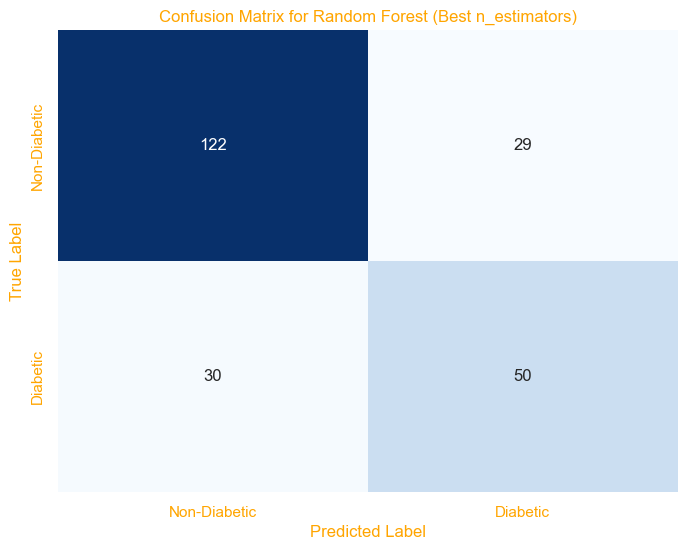


Classification Report:
              precision    recall  f1-score   support

Non-Diabetic       0.80      0.81      0.81       151
    Diabetic       0.63      0.62      0.63        80

    accuracy                           0.74       231
   macro avg       0.72      0.72      0.72       231
weighted avg       0.74      0.74      0.74       231



In [57]:
# Compute and plot the confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix for Random Forest (Best n_estimators)", color='orange')
plt.xlabel("Predicted Label", color='orange')
plt.ylabel("True Label", color='orange')
plt.xticks(ticks=[0.5, 1.5], labels=['Non-Diabetic', 'Diabetic'], color='orange')
plt.yticks(ticks=[0.5, 1.5], labels=['Non-Diabetic', 'Diabetic'], color='orange')
plt.show()

# Print the classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Non-Diabetic', 'Diabetic']))